<font color='#cb8ce1'>**SPRINT 8 - ANABEL MARTÍNEZ**</font>

<font color='#DA007F'>**NIVELL 1**</font>

Realitza la connexió en Python amb el MySQL Workbench per a carregar tota la informació que tens en les taules. Realitzaràs una visualització per a cada exercici. Comenta el que et crida l'atenció de graficar aquesta variable, justifica l'elecció del gràfic i interpreta els resultats en funció de les teves dades.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import seaborn as sns 
import numpy as np
from datetime import datetime

from scipy.stats import shapiro

db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="sales")

cursor = db.cursor()
sales = {}

cursor.execute("SHOW TABLES;")
table_names = [table[0] for table in cursor.fetchall()]

for table in table_names:
    query = f"SELECT * FROM {table}"
    df = pd.read_sql(query, con=db)
    sales[table] = df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2444\1998761298.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=db)


In [3]:
transactions_users = pd.merge(sales["transactions"], sales["users"], left_on="user_id", right_on="id", suffixes=("", "_tu"))
transactions_companies = pd.merge(sales["transactions"], sales["companies"], left_on= "business_id", right_on= "company_id")
transactions_tproducts = pd.merge(sales["transactions"], sales["transaction_products"], left_on= "id", right_on= "transaction_id")
tproducts_products = pd.merge(sales["transaction_products"], sales["products"], left_on= "product_id", right_on= "id")

transactions_users['birth_date'] = pd.to_datetime(transactions_users['birth_date'])

union_tablas = pd.merge(transactions_tproducts, tproducts_products, on=['transaction_id', 'product_id'])
union_tablas = pd.merge(union_tablas, transactions_users, left_on="transaction_id", right_on="id", suffixes=("", "_u"))
union_tablas = pd.merge(union_tablas, transactions_companies, left_on="transaction_id", right_on="id", suffixes=("", "_tc"))

columns_to_convert = ["product_id", "user_id", "id_y", "user_id_u", "id_tu", "user_id_tc"]
union_tablas[columns_to_convert] = union_tablas[columns_to_convert].astype(str)

columns_to_convert = ["declined", "declined_u", "declined_tc"]
union_tablas[columns_to_convert] = union_tablas[columns_to_convert].astype(bool)

<font color='#DA007F'>**Exercici 1**</font>

Una variable numèrica.

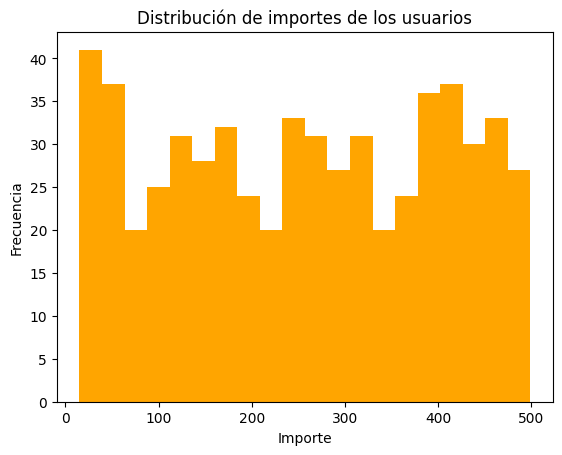

In [4]:
transactions_users["amount"].plot.hist(bins=20, color="orange")

plt.title("Distribución de importes de los usuarios")
plt.xlabel("Importe")
plt.ylabel("Frecuencia")
plt.show()

<u>Interpretación de los resultados:</u>

En este caso, he decidido elegir un histograma para visualizar una variable numérica ("amount" de "transactions_users") porque es un diagrama muy visual y que permite ver mucha información sobre la distribución de los importes de las transacciones.

En el caso de este diagrama, podemos ver que los importes que más se repiten son los que se encuentran entre los 0 y los 25 dólares, con una frecuencia superior a las 40 transacciones. Las transacciones con menor frecuencia son aquellas entre 50 y 75 dólares, entre 200 y 225 dólares, y entre 325 y 350 dólares. En general, la frecuencia se mueve entre un mínimo de 20 y un máximo de 40. Estos datos los he interpretado así teniendo en cuenta que he usado "20" bins, si hubiera ampliado ese rango, el gráfico también tendría un mayor nivel de desglose y podríamos ver una frecuencia más dispersa.

<font color='#DA007F'>**Exercici 2**</font>

Dues variables numèriques.

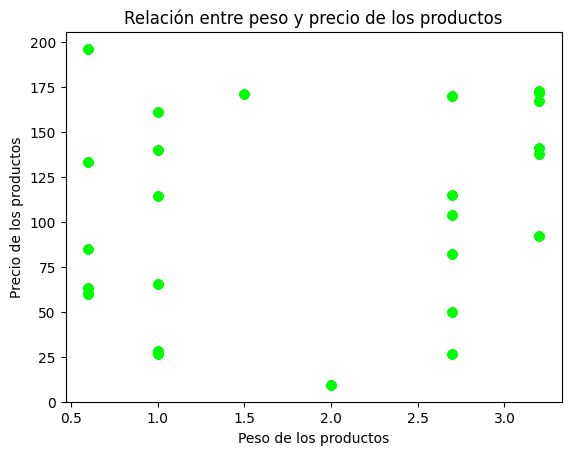

In [17]:
x = tproducts_products["weight"]
y = tproducts_products["price"]

plt.scatter(x,y, color='lime')
plt.xlabel("Peso de los productos")
plt.ylabel("Precio de los productos")
plt.title("Relación entre peso y precio de los productos")
plt.show()

<u>Interpretación de los resultados:</u>

Para estas dos variables numéricas, he decidido utilizar un scatterplot porque me ha parecido la mejor opción para observar si existe un patrón entre ambas, en este caso "weight" y "price" de la tabla "tproducts_products".

Este diagrama me demuestra que no hay una relación entre el peso y el precio de los productos, ya que no vemos que haya una progresión lineal entre lo que pesan los productos y lo que cuestan. En su lugar, observamos que un producto que pesa 0.5 kg, puede costar casi 200 dólares, mientras que un producto que pesa alrededor de 2.7 kg, cuesta poco más de 25 dólares. Además, también llama la atención que, para un mismo peso, como es el caso de 1 kg (o de 2.7 kg), el precio puede variar mucho, yendo desde los 25 dólares hasta los 160 dólares.

<font color='#DA007F'>**Exercici 3**</font>

Una variable categòrica.

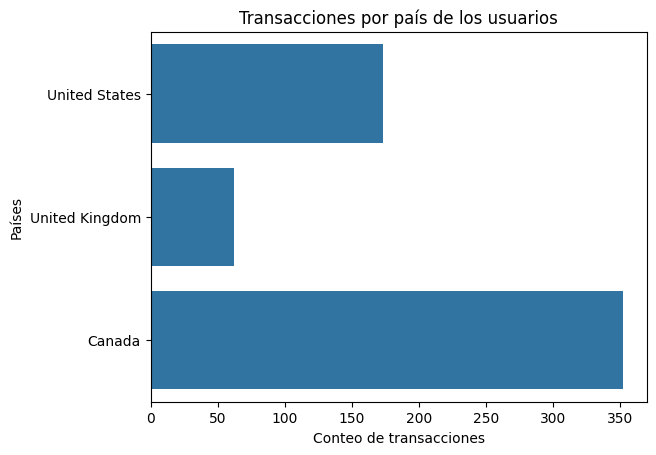

In [6]:
sns.countplot(data=transactions_users["country"])

plt.ylabel("Países")
plt.xlabel("Conteo de transacciones")
plt.title("Transacciones por país de los usuarios")
plt.show()

<u>Interpretación de los resultados:</u>

En este caso, he elegido realizar un gráfico "countplot" de la variable "country" de la tabla "transactions_users". Originalmente, había elegido un pie chart para realizar esta visualización, pero para poder realizarlo, necesitaba utilizar un "value_counts()" y no era lo ideal porque ya dejo de utilizar simplemente una variable categórica. Con este gráfico, sí que puedo ver el conteo de transacciones de los usuarios de cada país sin necesitar realizar acciones adicionales.

En este caso, se puede ver claramente que Canadá tiene la mayoría de las transacciones, con un  total de 350, después va Estados Unidos con alrededor de 180, y por último el Reino Unido, con alrededor de 60. Canadá es claramente el mercado más activo. De nuevo, esto no significa que sea donde hay más usuarios, si no que es allí desde donde se realiza un mayor número de compras.

Me llama mucho la atención que los usuarios de Estados Unidos realicen tan pocas compras, habría que estudiar causas e implementar planes de acción, ya que sí que es allí donde se concentra el mayor número de usuarios.

<font color='#DA007F'>**Exercici 4**</font>

Una variable categòrica i una numèrica.

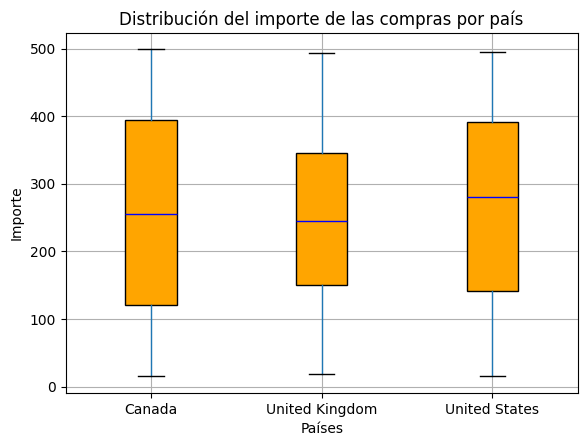

In [15]:
transactions_users.boxplot(column="amount", by="country", patch_artist=True, boxprops=dict(facecolor='orange'), medianprops=dict(color='blue'))

plt.title("Distribución del importe de las compras por país")
plt.suptitle("")  
plt.xlabel("Países")
plt.ylabel("Importe")
plt.show()


<u>Interpretación de los resultados:</u>

En este caso, decidí usar un boxplot para visualizar una variable categórica ("amount" de "transactions_users") y una numérica ("users" de "transactions_users") porque es un diagrama que muestra mucha información para cada país: muestra la mediana, el rango intercuartílico, la dispersión e incluso si hay outliers para cada uno de los importes.

Observo que la mediana de los tres ronda los 250 dólares, si bien la de Estados Unidos es la que supera claramente esa cifra, estando más bien entorno a los 280 dólares, Canadá supera ligeramente los 250, está entorno a 260, y Reino Unido no consigue llegar a los 250.

Si hablamos de la dispersión, vemos que Canadá y Estados Unidos tienen una mayor variabilidad en los importes de las compras, ya que se extienden aproximadamente entre los 100 y los 400. El Reino Unido tiene una distribución más limitada, que está entre 130 y 350. 

Los tres países se mueven en unos rangos similares, los bigotes empiezan y terminan en puntos similares y ninguno de los tres presenta outliers, por lo que están dentro de rangos razonables.

De este gráfico me parece interesante ver que los tres países tienen patrones de compra similares y sin valores extremos.

<font color='#DA007F'>**Exercici 5**</font>

Dues variables categòriques.

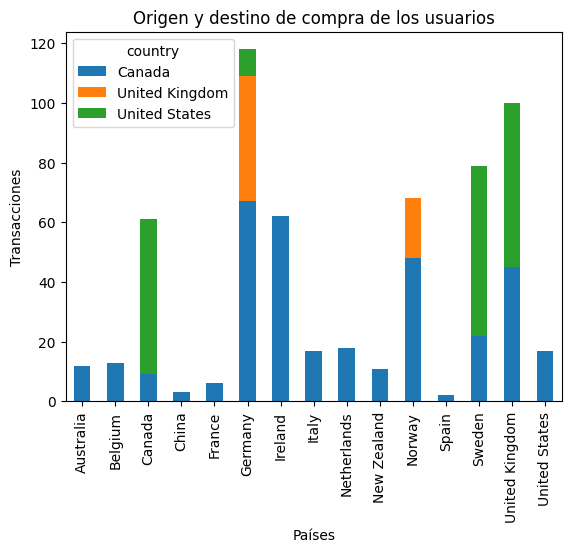

In [8]:
pd.crosstab(transactions_users["country"], transactions_companies["country"]).transpose().plot.bar(stacked = True)

plt.xlabel("Países")
plt.ylabel("Transacciones")
plt.title("Origen y destino de compra de los usuarios")
plt.show()

<u>Interpretación de los resultados:</u>

En este caso, elegí un gráfico de barras para mis dos variables categóricas porque así podría ver fácilmente cómo se distribuyen los datos para cada una de las dos variables, ver cómo se relacionan y ver la proporción de cada una.

He preferido usar un gráfico de barras apiladas porque me parece que es más fácil de entender visualmente: cada barra representa una combinación de variables.

Para este gráfico, he elegido la variable "country" de "transactions_users" y la variable "country" de "transactions_companies". Al haber recogido los datos de la unión de la tabla "users" con "transactions" y de la tabla "companies" con "transactions", el eje y nos muestra los datos de las transacciones que realizan los usuarios en cada país. Por ejemplo, vemos que los usuarios de Canadá realizan transacciones en los 15 países en los que hay empresas. Sin embargo, los usuarios de Estados Unidos solo realizan transacciones en Canadá, Alemania, Suecia y Reino Unido. Por último, los usuarios de Reino Unido realizan transacciones únicamente en Alemania y Noruega. Adicionalmente, este gráfico nos muestra que los 3 países con más transacciones son Alemania, Reino Unido y Suecia, con Alemania a la cabeza tanto en número de transacciones como en el hecho de que es el único que recibe compras por parte de los usuarios de los 3 países.

Este gráfico nos permite ver en qué países sería adecuado estudiar una posibilidad de mayor activación del mercado de ventas. También podemos ver en qué país los usuarios son más inactivos y, por tanto, se debería implementar algún tipo de campaña promocional para hacer crecer sus compras, sobre todo en países en los que aún no han comprado.

<font color='#DA007F'>**Exercici 6**</font>

Tres variables.

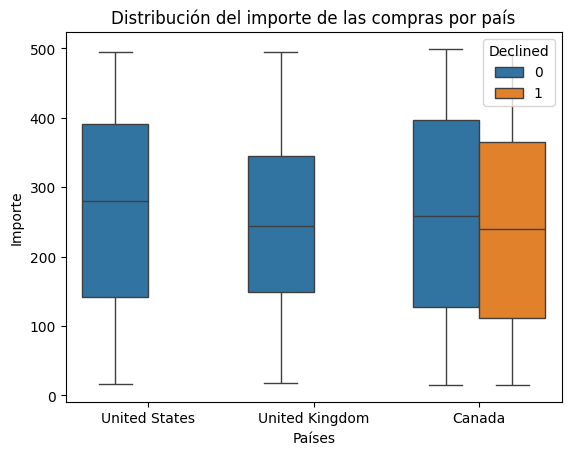

In [9]:
sns.boxplot(data=transactions_users, x = "country", y = "amount", hue = "declined")
plt.legend(title="Declined", loc='upper right')

plt.xlabel("Países")
plt.ylabel("Importe")
plt.title("Distribución del importe de las compras por país")
plt.show()

<u>Interpretación de los resultados:</u>

En este caso, he decidido utilizar un boxplot porque me permite comparar visualmente la distribución de las medianas de las compras de los usuarios de los varios países, así como los estados de las transacciones. Además, como proporciona tantos datos, en caso de haber una diferencia sustancial entre los tres países, podría identificarla.

Estos datos nos muestran que Estados Unidos tiene una mediana alta, de 290 dólares (anteriormente habíamos visto que la media se situaba alrededor de los 270). Además, vemos que no tiene transacciones rechazadas.

Reino Unido, por su parte, tiene una mediana de unos 250 dólares y tampoco cuenta con transacciones rechazadas.

Canadá, por último, tiene una mediana de unos 260 dólares. En este caso, es el único país con transacciones rechazadas. Además, la mediana de esas transacciones rechazadas es menor que la mediana de las aprobadas, es de unos 240 dólares. Esto resulta un poco contraintuitivo, porque uno asumiría que normalmente las transacciones rechazadas son las de más valor, pero no es el caso: las transacciones rechazadas son de menor valor que las aprobadas.

En general, ninguno de los tres países tiene outliers, los usuarios se mueven dentro de unos mismos rangos de cantidades en los tres países.

<font color='#DA007F'>**Exercici 7**</font>

Graficar un Pairplot.

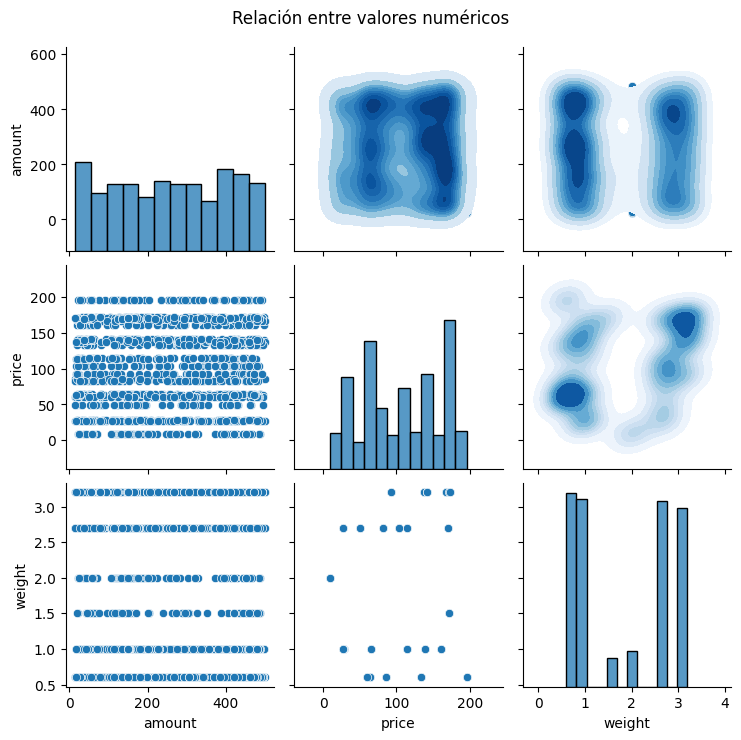

In [10]:
numeros = union_tablas[["amount", "price", "weight"]]


pp = sns.pairplot(data=numeros)
pp.map_upper(sns.kdeplot, fill="True", cmap="Blues")

plt.suptitle('Relación entre valores numéricos')
plt.subplots_adjust(top=0.93)
plt.show()

<u>Interpretación de los resultados:</u>

Este Pairplot muestra la relación entre las variables numéricas de los datos, que en este caso son "amount", "price" y "weight".

Mi conclusión es que no parece haber una relación entre ninguna de las variables:
  - Los puntos de "amount" y "price" están muy dispersos, por lo que no se muestra que haya una tendencia clara. El gráfico de densidad también muestra que hay una distribución uniforme, y eso me confirma aún más que hay una ausencia de correlación.
  - Los puntos de "amount" y "weight" están muy dispersos también. En el gráfico de densidad vemos que hay agrupaciones en ciertos rangos de pesos concreto, pero no hay un patrón establecido con amount. Todo esto me indica que no hay una relación fuerte.

  - "Price" y "weight" no tienen una correlación clara. Al igual que con "amount" y "weight", no hay una tendencia lineal que me muestre que hay una relación consistente. El gráfico de densidad muestra algunas zonas con más concentración, pero no hay dependencia entre las variables.

En este caso, las variables numéricas no guardan relación entre sí, pese a que en otros casos las relaciones entre variables numéricas son muy claras. En categorías de productos como los de supermercado, por ejemplo, el precio y el peso estarían muy relacionados, pero en este caso no es así.

<font color='#DA007F'>**NIVELL 2**</font>

<font color='#DA007F'>**Exercici 1**</font>

Correlació de totes les variables numèriques.

- Shapiro-Wilk para 'amount':
No parece seguir una distribución normal.
- Shapiro-Wilk para 'price':
No parece seguir una distribución normal.
- Shapiro-Wilk para 'weight':
No parece seguir una distribución normal.


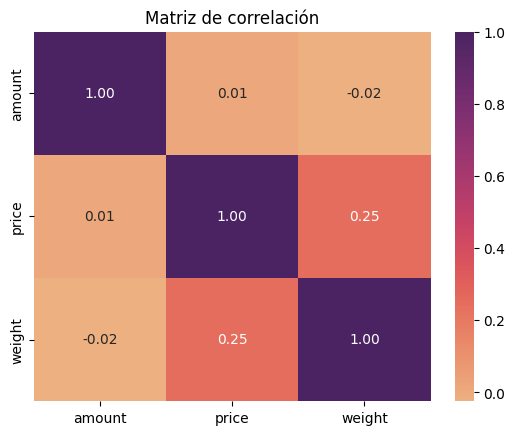

In [16]:
numeros = union_tablas[["amount", "price", "weight"]]

for columna in numeros.columns:
    stat, p = shapiro(numeros[columna].dropna())
    print(f"- Shapiro-Wilk para '{columna}':")
    if p > 0.05: 
        print("Parece seguir una distribución normal.")
    else:
        print("No parece seguir una distribución normal.")

corr = numeros.corr(method="spearman")

sns.heatmap(data=corr, annot=True, cmap="flare", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

<font color='#DA007F'>**Exercici 2**</font>

Implementa un jointplot.

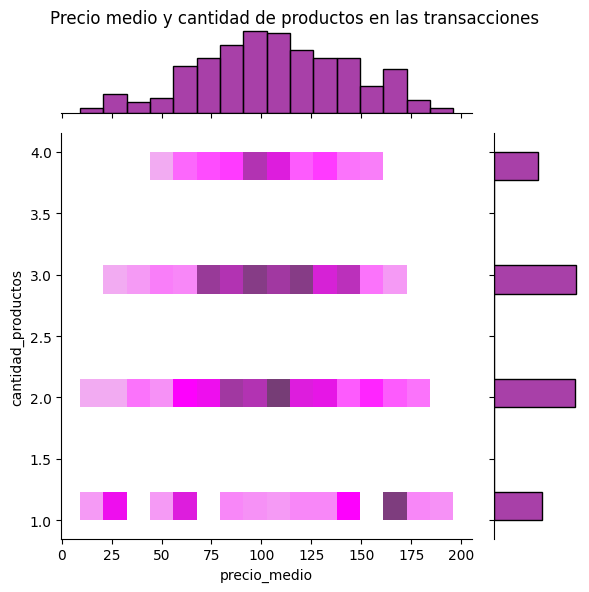

In [12]:
trans = tproducts_products.groupby('transaction_id').agg(precio_medio=('price', 'mean'),
                                                         cantidad_productos=('product_id',
                                                                           'count')).reset_index()


sns.jointplot(x='precio_medio', y='cantidad_productos', data=trans, ratio=4,
              kind='hist', color='darkmagenta')
plt.suptitle('Precio medio y cantidad de productos en las transacciones', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

<font color='#DA007F'>**NIVELL 3**</font>

<font color='#DA007F'>**Exercici 1**</font>

Implementa un violinplot combinat amb un altre tipus de gràfic.

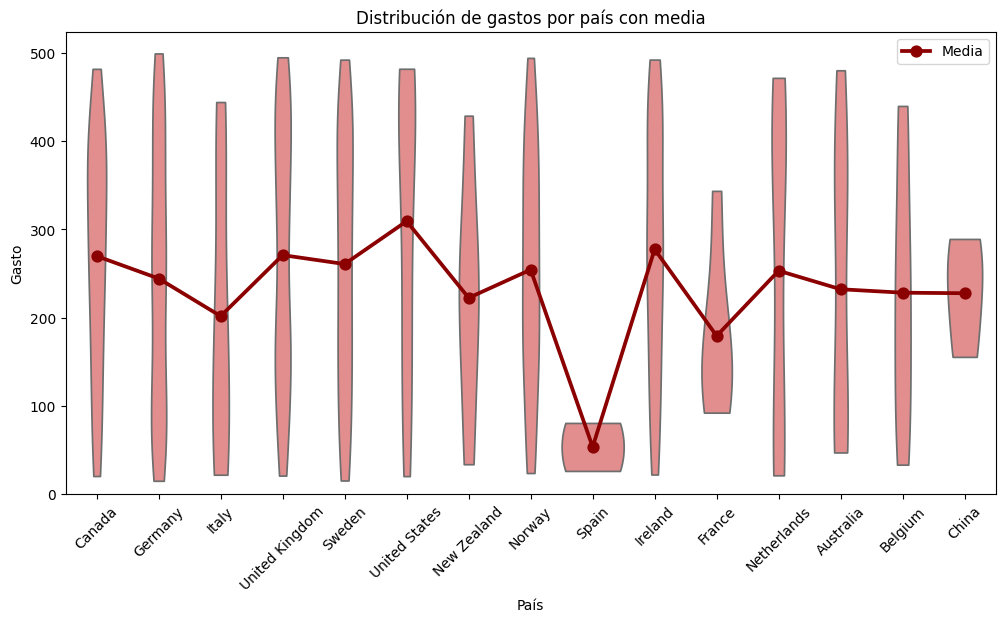

In [13]:
plt.figure(figsize=(12, 6))

dc = sns.violinplot(data=transactions_companies, x="country", y="amount", inner=None, color="lightcoral", width=1.0, cut=0)

means = transactions_companies.groupby("country")["amount"].mean().reset_index()

sns.pointplot(data=means, x="country", y="amount", color="darkred", label="Media")
plt.ylim(bottom=0)
plt.xlabel("País")    
plt.ylabel("Gasto")  

plt.xticks(rotation=45)
plt.title("Distribución de gastos por país con media")
plt.show()

<font color='#DA007F'>**Exercici 2**</font>

Genera un FacetGrid per a visualitzar múltiples aspectes de les dades simultàniament.

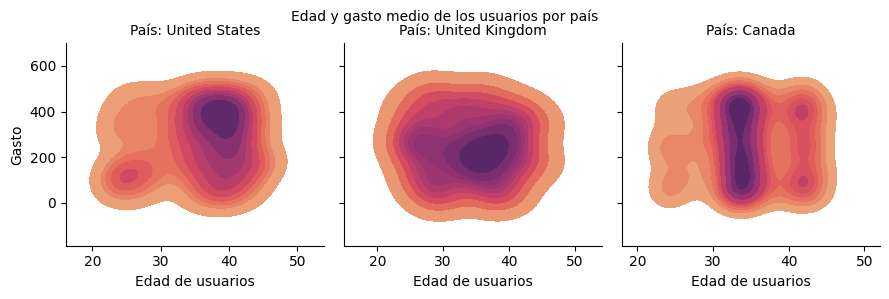

In [14]:
today = pd.Timestamp(datetime.today().date())
transactions_users['age'] = (today - transactions_users['birth_date']).dt.days // 365

fg = sns.FacetGrid(data=transactions_users, col='country', sharex=False)
fg.map_dataframe(sns.kdeplot, x="age", y="amount", fill=True, cmap="flare")

fg.set_axis_labels('Edad de usuarios', 'Gasto')

plt.suptitle('Edad y gasto medio de los usuarios por país', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(top=0.87)

fg.set_titles(col_template='País: {col_name}')
plt.show()